# Part 2: ResNet50 Model Improvement Ablations

This notebook keeps the Part 2 workflow notebook-owned while moving reusable training and result logic into project modules. The regular-training baseline is loaded from Part 1 results; the remaining ablations are trained here.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parents[1] if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

ROOT

PosixPath('/Users/royrubin/Documents/GitHub/MLDS_Final_Project')

In [2]:
import pandas as pd
from IPython.display import Image, display

from src.evaluation.experiment_results import (
    experiment_output_paths,
    get_device,
    load_part1_model_baseline_aggregated,
)
from src.training.experiment_steps import run_part2_improvement_experiments
from src.utils.config import Part2ExperimentConfig
from src.utils.reproducibility import seed_everything

/Users/royrubin/opt/anaconda3/envs/mlds_dogs_vs_cats/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

In [3]:
config = Part2ExperimentConfig()
device = get_device(config)
output_paths = experiment_output_paths(config.results_dir, config.figures_dir, config.part)
seed_everything(config.seed, deterministic=config.deterministic)

pd.DataFrame(
    [
        {
            'part': config.part,
            'config_name': config.config_name,
            'model_name': config.model_name,
            'grid_sizes': config.grid_sizes,
            'num_permutations': config.num_permutations,
            'epochs': config.epochs,
            'device': str(device),
        }
    ]
)

,part,config_name,model_name,grid_sizes,num_permutations,epochs,device
0,part2,part2_improvement,resnet50,"[1, 2]",3,5,cpu


In [4]:
pd.DataFrame(config.ablations)

,name,use_pretrained,use_standard_augmentation,freeze_backbone
0,pretrained_feature_extractor,True,False,True
1,pretrained_finetune,True,False,False
2,augmentation_only,False,True,False
3,pretrained_augmented_finetune,True,True,False


## Part 1 ResNet50 Baseline

In [5]:
part1_baseline_aggregated = load_part1_model_baseline_aggregated(config, config.model_name)
if not part1_baseline_aggregated.empty:
    display(part1_baseline_aggregated)

,model_name,grid_size,num_tiles,mean_val_accuracy,std_val_accuracy,mean_best_val_accuracy,std_best_val_accuracy,n_runs,ablation_name,config_name
4,resnet50,1,1,0.5,NaN,0.5,NaN,1,regular_part1,part2_improvement
5,resnet50,2,4,0.5,0.0,0.5,0.0,4,regular_part1,part2_improvement


## Train Improvement Ablations

In [6]:
RUN_TRAINING = True

if RUN_TRAINING:
    part2_results = run_part2_improvement_experiments(config=config, device=device)
    display(part2_results)
else:
    print('Training is skipped. Set RUN_TRAINING = True to train Part 2 ablations in this notebook.')


Running ablation: pretrained_feature_extractor

[1/5] grid=1x1, permutation_id=0, seed=42
Building training components for model 'resnet50'...
Finished building training components for model 'resnet50'.
Training model 'resnet50' for 5 epoch(s)...


Epoch:   0%|          | 0/5 [00:00<?, ?epoch/s]/Users/royrubin/Documents/GitHub/MLDS_Final_Project/src/training/engine.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp and device.type == "cuda")
/Users/royrubin/Documents/GitHub/MLDS_Final_Project/src/training/engine.py:62: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp and device.type == "cuda"):


Finished training model 'resnet50'. Metrics: {'train_loss': 0.5937738785376916, 'train_accuracy': 0.9230769230769231, 'val_loss': 0.5801939368247986, 'val_accuracy': 1.0, 'best_val_accuracy': 1.0}

[2/5] grid=2x2, permutation_id=0, seed=42
Building training components for model 'resnet50'...
Finished building training components for model 'resnet50'.
Training model 'resnet50' for 5 epoch(s)...


Finished training model 'resnet50'. Metrics: {'train_loss': 0.4700118624247037, 'train_accuracy': 1.0, 'val_loss': 0.6363627314567566, 'val_accuracy': 0.8333333333333334, 'best_val_accuracy': 0.8333333333333334}

[3/5] grid=2x2, permutation_id=1, seed=42
Building training components for model 'resnet50'...
Finished building training components for model 'resnet50'.
Training model 'resnet50' for 5 epoch(s)...


Finished training model 'resnet50'. Metrics: {'train_loss': 0.5195006498923669, 'train_accuracy': 0.9230769230769231, 'val_loss': 0.5468254685401917, 'val_accuracy': 0.8333333333333334, 'best_val_accuracy': 0.8333333333333334}

[4/5] grid=2x2, permutation_id=2, seed=42
Building training components for model 'resnet50'...
Finished building training components for model 'resnet50'.
Training model 'resnet50' for 5 epoch(s)...


...

Finished training model 'resnet50'. Metrics: {'train_loss': 0.04973609000444412, 'train_accuracy': 1.0, 'val_loss': 0.1961384415626526, 'val_accuracy': 1.0, 'best_val_accuracy': 1.0}

[3/5] grid=2x2, permutation_id=1, seed=42
Building training components for model 'resnet50'...
Finished building training components for model 'resnet50'.
Training model 'resnet50' for 5 epoch(s)...


Finished training model 'resnet50'. Metrics: {'train_loss': 0.06999689684464382, 'train_accuracy': 1.0, 'val_loss': 0.181387260556221, 'val_accuracy': 1.0, 'best_val_accuracy': 1.0}

[4/5] grid=2x2, permutation_id=2, seed=42
Building training components for model 'resnet50'...
Finished building training components for model 'resnet50'.
Training model 'resnet50' for 5 epoch(s)...


Finished training model 'resnet50'. Metrics: {'train_loss': 0.06801672050586113, 'train_accuracy': 1.0, 'val_loss': 0.2064695507287979, 'val_accuracy': 1.0, 'best_val_accuracy': 1.0}

[5/5] grid=2x2, permutation_id=3, seed=42
Building training components for model 'resnet50'...
Finished building training components for model 'resnet50'.
Training model 'resnet50' for 5 epoch(s)...


Finished training model 'resnet50'. Metrics: {'train_loss': 0.07216497453359458, 'train_accuracy': 1.0, 'val_loss': 0.373869925737381, 'val_accuracy': 0.8333333333333334, 'best_val_accuracy': 1.0}


,model_name,ablation_name,grid_size,num_tiles,mean_val_accuracy,std_val_accuracy,mean_best_val_accuracy,std_best_val_accuracy,n_runs
0,resnet50,augmentation_only,1,1,0.500000,NaN,0.500000,NaN,1
1,resnet50,augmentation_only,2,4,0.500000,0.000000,0.541667,0.083333,4
2,resnet50,pretrained_augmented_finetune,1,1,1.000000,NaN,1.000000,NaN,1
3,resnet50,pretrained_augmented_finetune,2,4,0.958333,0.083333,1.000000,0.000000,4
4,resnet50,pretrained_feature_extractor,1,1,1.000000,NaN,1.000000,NaN,1
5,resnet50,pretrained_feature_extractor,2,4,0.875000,0.083333,0.916667,0.096225,4
6,resnet50,pretrained_finetune,1,1,1.000000,NaN,1.000000,NaN,1
7,resnet50,pretrained_finetune,2,4,1.000000,0.000000,1.000000,0.000000,4
8,resnet50,regular_part1,1,1,0.500000,NaN,0.500000,NaN,1
9,resnet50,regular_part1,2,4,0.500000,0.000000,0.500000,0.000000,4


## Results

In [7]:
results_path = Path(output_paths['aggregated_results'])

if results_path.exists():
    part2_results = pd.read_csv(results_path)
    if 'regular_part1' not in set(part2_results.get('ablation_name', [])) and not part1_baseline_aggregated.empty:
        part2_results = pd.concat([part1_baseline_aggregated, part2_results], ignore_index=True, sort=False)
    display(part2_results.sort_values(['grid_size', 'ablation_name']))
else:
    print('Part 2 aggregated results were not found. Set RUN_TRAINING = True and run the training cell.')
    if part1_baseline_aggregated.empty:
        print('Part 1 ResNet50 baseline results were also not found; run Part 1 first to include regular_part1.')

,model_name,ablation_name,grid_size,num_tiles,mean_val_accuracy,std_val_accuracy,mean_best_val_accuracy,std_best_val_accuracy,n_runs
0,resnet50,augmentation_only,1,1,0.500000,NaN,0.500000,NaN,1
2,resnet50,pretrained_augmented_finetune,1,1,1.000000,NaN,1.000000,NaN,1
4,resnet50,pretrained_feature_extractor,1,1,1.000000,NaN,1.000000,NaN,1
6,resnet50,pretrained_finetune,1,1,1.000000,NaN,1.000000,NaN,1
8,resnet50,regular_part1,1,1,0.500000,NaN,0.500000,NaN,1
1,resnet50,augmentation_only,2,4,0.500000,0.000000,0.541667,0.083333,4
3,resnet50,pretrained_augmented_finetune,2,4,0.958333,0.083333,1.000000,0.000000,4
5,resnet50,pretrained_feature_extractor,2,4,0.875000,0.083333,0.916667,0.096225,4
7,resnet50,pretrained_finetune,2,4,1.000000,0.000000,1.000000,0.000000,4
9,resnet50,regular_part1,2,4,0.500000,0.000000,0.500000,0.000000,4


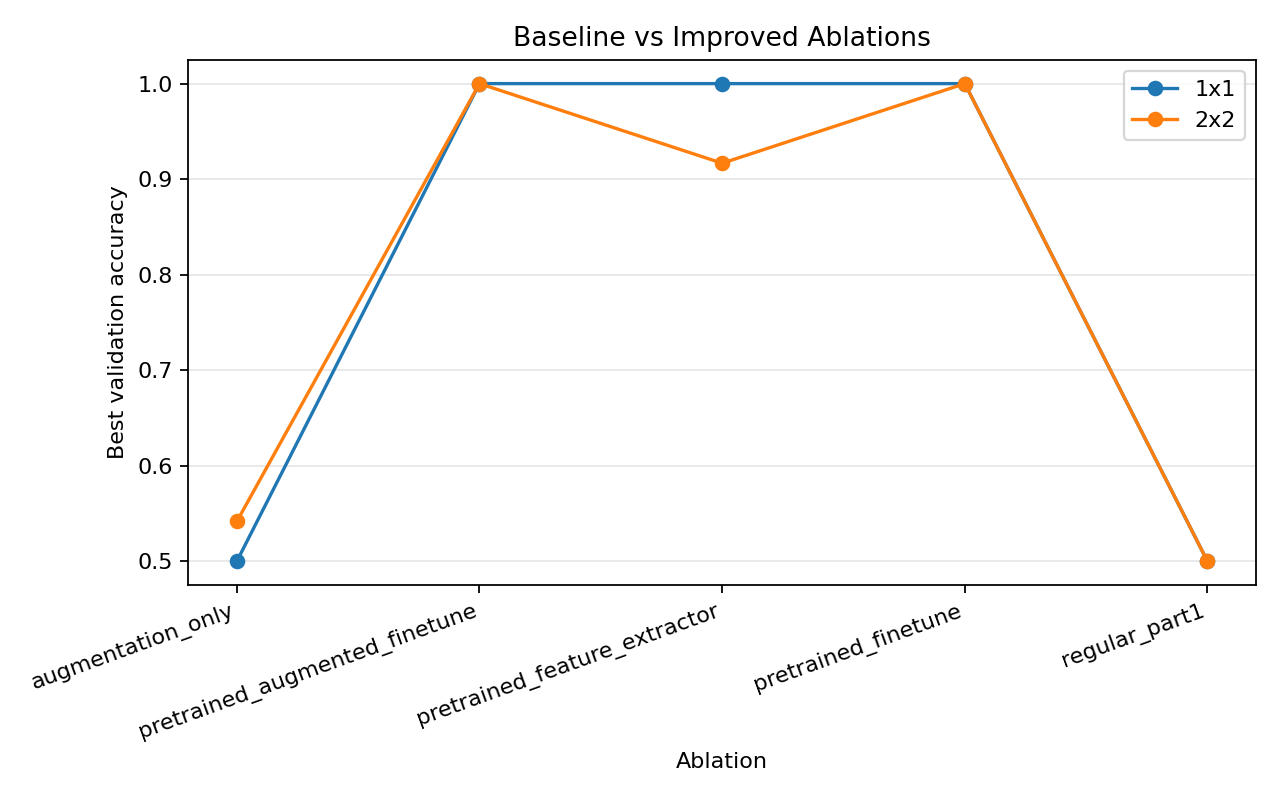

In [8]:
figure_path = Path(output_paths['figure'])
if figure_path.exists():
    display(Image(filename=str(figure_path)))
else:
    print('Part 2 ablation figure has not been generated yet.')